In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime


#Data Collection

In [2]:
import pandas as pd
from datetime import datetime

# Load CSV
ticker = 'ADBL'
df = pd.read_csv(f'{ticker}.csv')

# Convert 'published_date' to datetime
df['published_date'] = pd.to_datetime(df['published_date'], errors='coerce')

# Drop rows where date conversion failed
df = df.dropna(subset=['published_date'])

# Filter last 10 years
now = datetime.now()
start = datetime(now.year - 10, now.month, now.day)
df = df[(df['published_date'] >= start) & (df['published_date'] <= now)]

# Drop unwanted columns
columns_to_remove = ['per_change', 'traded_amount', 'status']
df = df.drop(columns=columns_to_remove)

# Reset index
df = df.reset_index(drop=True)

# Display nicely in Jupyter
df


,published_date,open,high,low,close,traded_quantity
0,2015-11-08,460.0,462.0,451.0,462.0,607.0
1,2015-11-09,462.0,483.0,469.0,483.0,4949.0
2,2015-11-10,483.0,485.0,474.0,477.0,8443.0
3,2015-11-15,477.0,475.0,470.0,475.0,1170.0
4,2015-11-16,475.0,471.0,467.0,471.0,250.0
...,...,...,...,...,...,...
2289,2025-10-30,316.6,319.9,310.0,313.5,28033.0
2290,2025-11-02,319.7,325.9,313.0,315.0,34431.0
2291,2025-11-03,320.3,320.3,312.0,317.0,26537.0
2292,2025-11-04,322.0,322.0,309.1,312.0,56192.0


In [3]:
df.head()

,published_date,open,high,low,close,traded_quantity
0,2015-11-08,460.0,462.0,451.0,462.0,607.0
1,2015-11-09,462.0,483.0,469.0,483.0,4949.0
2,2015-11-10,483.0,485.0,474.0,477.0,8443.0
3,2015-11-15,477.0,475.0,470.0,475.0,1170.0
4,2015-11-16,475.0,471.0,467.0,471.0,250.0


In [4]:
df.tail()

,published_date,open,high,low,close,traded_quantity
2289,2025-10-30,316.6,319.9,310.0,313.5,28033.0
2290,2025-11-02,319.7,325.9,313.0,315.0,34431.0
2291,2025-11-03,320.3,320.3,312.0,317.0,26537.0
2292,2025-11-04,322.0,322.0,309.1,312.0,56192.0
2293,2025-11-05,309.1,315.0,308.0,315.0,41787.0


2. Data Exploration & Visualization

In [5]:
type(df)


pandas.core.frame.DataFrame

In [6]:
df.shape

(2294, 6)

In [7]:
df.isna().sum()

published_date     0
open               0
high               0
low                0
close              0
traded_quantity    0
dtype: int64

In [8]:
df.describe()


,published_date,open,high,low,close,traded_quantity
count,2294,2294.000000,2294.000000,2294.000000,2294.000000,2294.000000
mean,2020-10-29 07:09:21.813426432,402.028714,407.321835,396.124063,401.560344,38225.156059
min,2015-11-08 00:00:00,223.000000,225.000000,223.000000,223.400000,60.000000
25%,2018-05-02 06:00:00,315.000000,318.000000,310.625000,314.775000,10570.750000
50%,2020-12-08 12:00:00,382.000000,387.000000,376.000000,381.200000,21242.000000
75%,2023-04-29 06:00:00,449.000000,453.000000,442.000000,448.000000,42737.750000
max,2025-11-05 00:00:00,1082.000000,1113.000000,1048.000000,1082.000000,800592.000000
std,NaN,135.712705,138.564824,133.042513,136.401507,56036.973456


In [9]:
df.dtypes

published_date     datetime64[ns]
open                      float64
high                      float64
low                       float64
close                     float64
traded_quantity           float64
dtype: object

In [10]:
df.head()

,published_date,open,high,low,close,traded_quantity
0,2015-11-08,460.0,462.0,451.0,462.0,607.0
1,2015-11-09,462.0,483.0,469.0,483.0,4949.0
2,2015-11-10,483.0,485.0,474.0,477.0,8443.0
3,2015-11-15,477.0,475.0,470.0,475.0,1170.0
4,2015-11-16,475.0,471.0,467.0,471.0,250.0


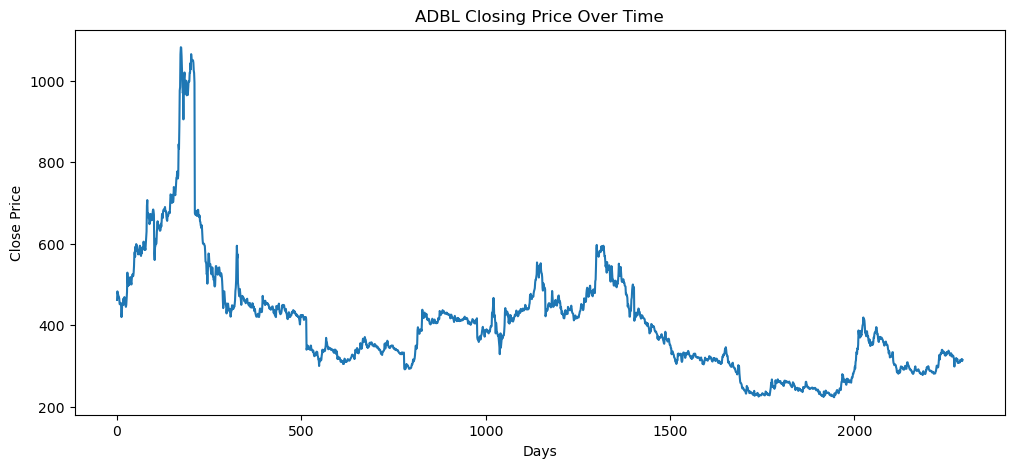

In [11]:

plt.figure(figsize=(12, 5))
plt.plot(df.close)
plt.title(f'{ticker} Closing Price Over Time')
plt.xlabel('Days')
plt.ylabel('Close Price')
plt.show()


3. Feature Engineering

In [12]:
temp_df = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

# Slice from index 2 to 6 (2:7) and take the average
print(sum(temp_df[2:7]) / 5)



50.0


In [13]:
df1 = pd.DataFrame([10, 20, 30, 40, 50, 60, 70, 80, 90, 100])
df1

,0
0,10
1,20
2,30
3,40
4,50
5,60
6,70
7,80
8,90
9,100


In [14]:
df1['MA_5'] = df1.rolling(5).mean()
df1

,0,MA_5
0,10,NaN
1,20,NaN
2,30,NaN
3,40,NaN
4,50,30.0
5,60,40.0
6,70,50.0
7,80,60.0
8,90,70.0
9,100,80.0


100 days Moving Average

In [15]:
df['MA_100']= df.close.rolling(100).mean()
df.head()

,published_date,open,high,low,close,traded_quantity,MA_100
0,2015-11-08,460.0,462.0,451.0,462.0,607.0,NaN
1,2015-11-09,462.0,483.0,469.0,483.0,4949.0,NaN
2,2015-11-10,483.0,485.0,474.0,477.0,8443.0,NaN
3,2015-11-15,477.0,475.0,470.0,475.0,1170.0,NaN
4,2015-11-16,475.0,471.0,467.0,471.0,250.0,NaN


In [16]:
df.head(103)

,published_date,open,high,low,close,traded_quantity,MA_100
0,2015-11-08,460.0,462.0,451.0,462.0,607.0,NaN
1,2015-11-09,462.0,483.0,469.0,483.0,4949.0,NaN
2,2015-11-10,483.0,485.0,474.0,477.0,8443.0,NaN
3,2015-11-15,477.0,475.0,470.0,475.0,1170.0,NaN
4,2015-11-16,475.0,471.0,467.0,471.0,250.0,NaN
...,...,...,...,...,...,...,...
98,2016-04-05,680.0,685.0,670.0,684.0,22777.0,NaN
99,2016-04-06,684.0,689.0,677.0,680.0,17535.0,553.28
100,2016-04-10,680.0,685.0,670.0,671.0,35135.0,555.37
101,2016-04-11,583.0,584.0,572.0,576.0,2445.0,556.30


Text(0, 0.5, 'Price')

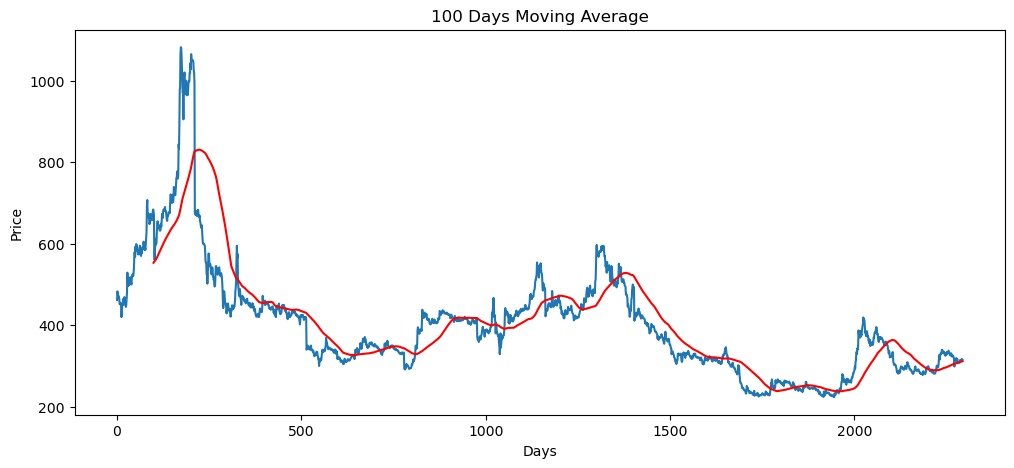

In [17]:
plt.figure(figsize=(12, 5))
plt.plot(df.close)
plt.plot(df['MA_100'],'r')
plt.title('100 Days Moving Average')
plt.xlabel('Days')
plt.ylabel('Price')



200 Days Moving Average

In [18]:
df['MA_200']= df.close.rolling(200).mean()
df.head(203)

,published_date,open,high,low,close,traded_quantity,MA_100,MA_200
0,2015-11-08,460.0,462.0,451.0,462.0,607.0,NaN,NaN
1,2015-11-09,462.0,483.0,469.0,483.0,4949.0,NaN,NaN
2,2015-11-10,483.0,485.0,474.0,477.0,8443.0,NaN,NaN
3,2015-11-15,477.0,475.0,470.0,475.0,1170.0,NaN,NaN
4,2015-11-16,475.0,471.0,467.0,471.0,250.0,NaN,NaN
...,...,...,...,...,...,...,...,...
198,2016-09-04,998.0,1029.0,989.0,1020.0,13611.0,776.23,NaN
199,2016-09-05,1020.0,1056.0,1020.0,1043.0,34803.0,779.86,666.570
200,2016-09-06,1043.0,1055.0,1011.0,1028.0,25608.0,783.43,669.400
201,2016-09-07,1028.0,1065.0,1011.0,1065.0,62511.0,788.32,672.310


Text(0, 0.5, 'Price')

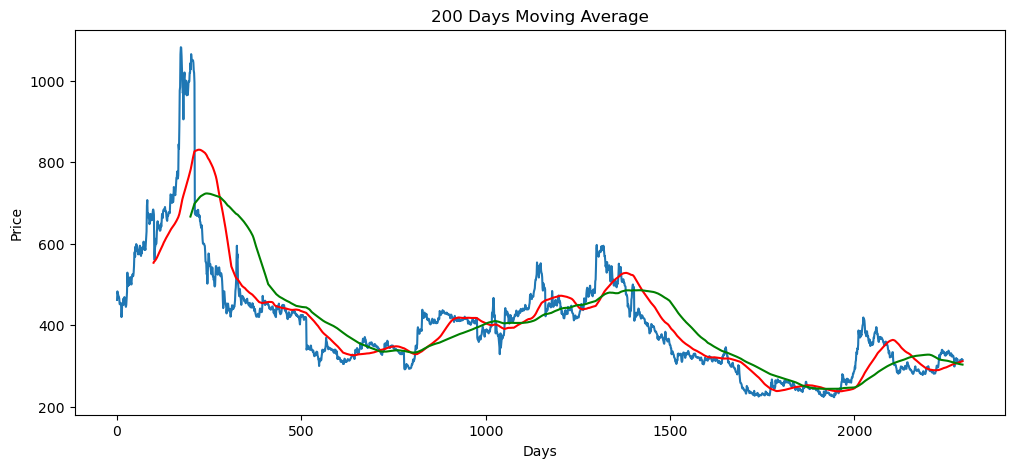

In [19]:
plt.figure(figsize=(12, 5))
plt.plot(df.close)
plt.plot(df['MA_100'],'r')
plt.plot(df['MA_200'],'g')
plt.title('200 Days Moving Average')
plt.xlabel('Days')
plt.ylabel('Price')

Calculating % changed in trading session

In [20]:
df['Percentage Changed']= df.close.pct_change()
df[['close', 'Percentage Changed']]

,close,Percentage Changed
0,462.0,NaN
1,483.0,0.045455
2,477.0,-0.012422
3,475.0,-0.004193
4,471.0,-0.008421
...,...,...
2289,313.5,0.004808
2290,315.0,0.004785
2291,317.0,0.006349
2292,312.0,-0.015773


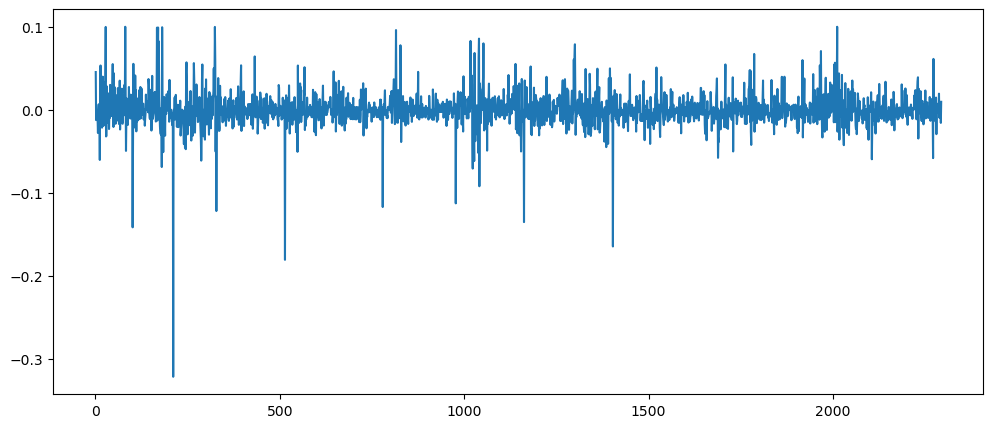

In [21]:
plt.figure(figsize=(12, 5))
plt.plot(df['Percentage Changed'])

4. Data Preprocessing

In [22]:
df.shape

(2294, 9)

In [23]:
# Spliiting data into Training and Testing datasets
data_training = pd.DataFrame(df.close[0:int(len(df)*0.7)])
data_testing = pd.DataFrame(df.close[int(len(df)*0.7): int(len(df))])

print(data_training)
print(data_testing)

      close
0     462.0
1     483.0
2     477.0
3     475.0
4     471.0
...     ...
1600  316.0
1601  313.5
1602  313.0
1603  316.0
1604  317.9

[1605 rows x 1 columns]
      close
1605  317.5
1606  324.0
1607  324.0
1608  319.0
1609  322.0
...     ...
2289  313.5
2290  315.0
2291  317.0
2292  312.0
2293  315.0

[689 rows x 1 columns]


In [24]:
type(data_training)

pandas.core.frame.DataFrame

In [25]:
data_training

,close
0,462.0
1,483.0
2,477.0
3,475.0
4,471.0
...,...
1600,316.0
1601,313.5
1602,313.0
1603,316.0


In [26]:
data_testing

,close
1605,317.5
1606,324.0
1607,324.0
1608,319.0
1609,322.0
...,...
2289,313.5
2290,315.0
2291,317.0
2292,312.0


In [27]:
# Scaling down the data between 0 and 1

In [28]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))

In [29]:
data_training_array = scaler.fit_transform(data_training)
data_training_array

array([[0.21518987],
       [0.24177215],
       [0.23417722],
       ...,
       [0.02658228],
       [0.03037975],
       [0.03278481]], shape=(1605, 1))

In [30]:
type(data_training_array)

numpy.ndarray

In [31]:
data_training_array.shape

(1605, 1)

5. Sequence Creation 

In [32]:
x_train =[]
y_train=[]

for i in range(100,data_training_array.shape[0]):
    x_train.append(data_training_array[i-100:i])
    y_train.append(data_training_array[i,0])

x_train,y_train = np.array(x_train),np.array(y_train)

In [33]:
x_train

array([[[0.21518987],
        [0.24177215],
        [0.23417722],
        ...,
        [0.49113924],
        [0.49620253],
        [0.49113924]],

       [[0.24177215],
        [0.23417722],
        [0.23164557],
        ...,
        [0.49620253],
        [0.49113924],
        [0.47974684]],

       [[0.23417722],
        [0.23164557],
        [0.22658228],
        ...,
        [0.49113924],
        [0.47974684],
        [0.35949367]],

       ...,

       [[0.06518987],
        [0.06455696],
        [0.04670886],
        ...,
        [0.03025316],
        [0.03037975],
        [0.02721519]],

       [[0.06455696],
        [0.04670886],
        [0.05316456],
        ...,
        [0.03037975],
        [0.02721519],
        [0.02658228]],

       [[0.04670886],
        [0.05316456],
        [0.05443038],
        ...,
        [0.02721519],
        [0.02658228],
        [0.03037975]]], shape=(1505, 100, 1))

In [34]:
x_train.ndim

3

In [35]:
y_train.ndim

1

In [36]:
x_train.shape

(1505, 100, 1)

In [37]:
y_train.shape

(1505,)

6. Model Building

In [40]:
import tensorflow as tf
print(tf.__version__)

2.20.0


In [42]:
# ML Model
from keras.models import Sequential
from keras.layers import Dense,LSTM,Input

In [43]:
model = Sequential()

model.add(Input(shape = (100,1)))
model.add(LSTM(units = 128, activation = 'tanh', return_sequences = True))
model.add(LSTM(units = 64))
model.add(Dense(25))
model.add(Dense(1))

7. Model Training

In [45]:
model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(x_train, y_train, epochs=50)


Epoch 1/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 109ms/step - loss: 0.0065
Epoch 2/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 6s 131ms/step - loss: 0.0016
Epoch 3/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 6s 115ms/step - loss: 0.0014
Epoch 4/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 6s 128ms/step - loss: 0.0013
Epoch 5/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 99ms/step - loss: 0.0012    
Epoch 6/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 107ms/step - loss: 0.0049
Epoch 7/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 113ms/step - loss: 9.6497e-04
Epoch 8/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 6s 118ms/step - loss: 8.4317e-04
Epoch 9/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 6s 133ms/step - loss: 7.8187e-04
Epoch 10/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 6s 116ms/step - loss: 7.2879e-04
Epoch 11/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 6s 117ms/step - loss: 7.2235e-04
Epoch 12/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 6s 129ms/step - loss: 6.8806e-04
Epoch 13/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 6s 121ms/step - loss: 6.5594e-04
Epoch 14/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 6s 124ms/step - loss: 6.1181e-04
Epoch 15/50
48/48 ━━━━

In [46]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┓
┃ Layer (type)                       ┃ Output Shape               ┃        Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                        │ (None, 100, 128)           │         66,560 │
├────────────────────────────────────┼────────────────────────────┼────────────────┤
│ lstm_1 (LSTM)                      │ (None, 64)                 │         49,408 │
├────────────────────────────────────┼────────────────────────────┼────────────────┤
│ dense (Dense)                      │ (None, 25)                 │          1,625 │
├────────────────────────────────────┼────────────────────────────┼────────────────┤
│ dense_1 (Dense)                    │ (None, 1)                  │             26 │
└────────────────────────────────────┴────────────────────────────┴────────────────┘

 Total params: 352,859 (1.35 MB)

 Trainable params: 117,619 (459.45 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 235,240 (918.91 KB)

In [48]:
# Save the trained model
model.save('stock_prediction_model.keras')

8. Preparing Test Data

In [50]:
data_training

,close
0,462.0
1,483.0
2,477.0
3,475.0
4,471.0
...,...
1600,316.0
1601,313.5
1602,313.0
1603,316.0


In [49]:
data_testing

,close
1605,317.5
1606,324.0
1607,324.0
1608,319.0
1609,322.0
...,...
2289,313.5
2290,315.0
2291,317.0
2292,312.0


In [55]:
past_100_days = data_training.tail(100)

In [52]:
past_100_days

,close
1595,320.5
1596,316.0
1597,316.0
1598,317.0
1599,315.9
1600,316.0
1601,313.5
1602,313.0
1603,316.0
1604,317.9


In [56]:
final_df = pd.concat([past_100_days, data_testing], ignore_index = True)
final_df

,close
0,334.0
1,335.0
2,335.6
3,332.0
4,328.5
...,...
784,313.5
785,315.0
786,317.0
787,312.0


In [57]:
input_data = scaler.fit_transform(final_df)
input_data

array([[0.56543967],
       [0.57055215],
       [0.57361963],
       [0.55521472],
       [0.53732106],
       [0.52965235],
       [0.49897751],
       [0.49335378],
       [0.48364008],
       [0.44580777],
       [0.44785276],
       [0.44274029],
       [0.41717791],
       [0.43762781],
       [0.46881391],
       [0.46319018],
       [0.54498978],
       [0.52709611],
       [0.54754601],
       [0.52453988],
       [0.52965235],
       [0.5398773 ],
       [0.54447853],
       [0.53476483],
       [0.54498978],
       [0.50920245],
       [0.45501022],
       [0.44274029],
       [0.45603272],
       [0.51891616],
       [0.55010225],
       [0.5603272 ],
       [0.5603272 ],
       [0.55623722],
       [0.54498978],
       [0.52453988],
       [0.49386503],
       [0.5194274 ],
       [0.55470348],
       [0.53425358],
       [0.5398773 ],
       [0.5408998 ],
       [0.5398773 ],
       [0.5700409 ],
       [0.5807771 ],
       [0.57055215],
       [0.55470348],
       [0.530

In [58]:
input_data.shape

(789, 1)

In [59]:
x_test = []
y_test = []

for i in range(100,input_data.shape[0]):
    x_test.append(input_data[i-100:i])
    y_test.append(input_data[i,0])

In [61]:
x_test, y_test = np.array(x_test),np.array(y_test)

In [62]:
x_test

array([[[0.56543967],
        [0.57055215],
        [0.57361963],
        ...,
        [0.45807771],
        [0.47341513],
        [0.48312883]],

       [[0.57055215],
        [0.57361963],
        [0.55521472],
        ...,
        [0.47341513],
        [0.48312883],
        [0.48108384]],

       [[0.57361963],
        [0.55521472],
        [0.53732106],
        ...,
        [0.48312883],
        [0.48108384],
        [0.51431493]],

       ...,

       [[0.2950409 ],
        [0.29120654],
        [0.30357873],
        ...,
        [0.45296524],
        [0.46063395],
        [0.46830266]],

       [[0.29120654],
        [0.30357873],
        [0.33742331],
        ...,
        [0.46063395],
        [0.46830266],
        [0.47852761]],

       [[0.30357873],
        [0.33742331],
        [0.33686094],
        ...,
        [0.46830266],
        [0.47852761],
        [0.45296524]]], shape=(689, 100, 1))

In [64]:
x_test[0].shape

(100, 1)

9. Making Predictions

In [65]:
y_predicted = model.predict(x_test)

y_predicted

22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step


array([[0.45958054],
       [0.4624892 ],
       [0.48393932],
       [0.49380141],
       [0.4755871 ],
       [0.4752379 ],
       [0.47611144],
       [0.47742006],
       [0.4619619 ],
       [0.44513237],
       [0.43223974],
       [0.4274574 ],
       [0.44194877],
       [0.44870165],
       [0.46592832],
       [0.47063768],
       [0.461665  ],
       [0.46332508],
       [0.45793638],
       [0.4401984 ],
       [0.4403602 ],
       [0.4538436 ],
       [0.4640884 ],
       [0.4619224 ],
       [0.45074058],
       [0.43415993],
       [0.41978863],
       [0.41193283],
       [0.42002937],
       [0.43449217],
       [0.43469137],
       [0.4269012 ],
       [0.4089709 ],
       [0.40538982],
       [0.40219483],
       [0.41019714],
       [0.4121967 ],
       [0.43852842],
       [0.4804998 ],
       [0.49197316],
       [0.50731057],
       [0.5042262 ],
       [0.4996842 ],
       [0.5098971 ],
       [0.53706   ],
       [0.5764952 ],
       [0.57963   ],
       [0.593

In [66]:
y_test

array([0.48108384, 0.51431493, 0.51431493, 0.48875256, 0.50408998,
       0.49897751, 0.49897751, 0.47597137, 0.46319018, 0.45143149,
       0.44785276, 0.46830266, 0.46574642, 0.49130879, 0.48875256,
       0.47852761, 0.48875256, 0.47597137, 0.45347648, 0.46472393,
       0.47852761, 0.48364008, 0.47852761, 0.46830266, 0.45143149,
       0.43762781, 0.4299591 , 0.44274029, 0.45552147, 0.44836401,
       0.44274029, 0.42229039, 0.42740286, 0.41820041, 0.4309816 ,
       0.42689162, 0.46830266, 0.5107362 , 0.50613497, 0.53476483,
       0.52453988, 0.52453988, 0.5398773 , 0.56799591, 0.60633947,
       0.59611452, 0.62678937, 0.59611452, 0.54601227, 0.53476483,
       0.51431493, 0.51431493, 0.45347648, 0.43251534, 0.44887526,
       0.43251534, 0.41768916, 0.40541922, 0.39672802, 0.39161554,
       0.38394683, 0.38139059, 0.38139059, 0.41411043, 0.42740286,
       0.43251534, 0.39263804, 0.38394683, 0.37167689, 0.36605317,
       0.35582822, 0.3609407 , 0.33588957, 0.3200409 , 0.31492

In [67]:
y_predicted = scaler.inverse_transform(y_predicted.reshape(-1,1)).flatten()
y_test = scaler.inverse_transform(y_test.reshape(-1,1)).flatten()

In [68]:
y_predicted

array([313.29395, 313.86288, 318.05853, 319.98755, 316.42484, 316.35654,
       316.5274 , 316.7834 , 313.75974, 310.4679 , 307.9461 , 307.01065,
       309.84518, 311.16605, 314.53558, 315.45673, 313.7017 , 314.02637,
       312.97235, 309.5028 , 309.53445, 312.1718 , 314.1757 , 313.752  ,
       311.56485, 308.3217 , 305.51065, 303.97406, 305.55774, 308.38666,
       308.42563, 306.9019 , 303.39468, 302.69424, 302.0693 , 303.63455,
       304.02567, 309.17615, 317.38574, 319.62994, 322.62994, 322.02664,
       321.13824, 323.13586, 328.44894, 336.16245, 336.77563, 339.41534,
       335.6045 , 326.05478, 321.3149 , 318.8055 , 319.0373 , 311.51245,
       305.0045 , 305.45728, 305.13516, 303.0531 , 300.43527, 298.4154 ,
       297.32816, 296.27875, 295.62796, 295.44324, 299.49017, 303.32196,
       304.98187, 299.7239 , 295.60568, 293.21228, 292.32272, 291.1522 ,
       291.20804, 288.29355, 284.72293, 282.77078, 282.49277, 281.00717,
       278.6184 , 280.2047 , 285.81122, 295.4692 , 

In [69]:
y_test

array([317.5 , 324.  , 324.  , 319.  , 322.  , 321.  , 321.  , 316.5 ,
       314.  , 311.7 , 311.  , 315.  , 314.5 , 319.5 , 319.  , 317.  ,
       319.  , 316.5 , 312.1 , 314.3 , 317.  , 318.  , 317.  , 315.  ,
       311.7 , 309.  , 307.5 , 310.  , 312.5 , 311.1 , 310.  , 306.  ,
       307.  , 305.2 , 307.7 , 306.9 , 315.  , 323.3 , 322.4 , 328.  ,
       326.  , 326.  , 329.  , 334.5 , 342.  , 340.  , 346.  , 340.  ,
       330.2 , 328.  , 324.  , 324.  , 312.1 , 308.  , 311.2 , 308.  ,
       305.1 , 302.7 , 301.  , 300.  , 298.5 , 298.  , 298.  , 304.4 ,
       307.  , 308.  , 300.2 , 298.5 , 296.1 , 295.  , 293.  , 294.  ,
       289.1 , 286.  , 285.  , 285.  , 282.  , 279.3 , 283.9 , 291.  ,
       302.  , 298.5 , 299.  , 281.7 , 272.  , 261.5 , 258.2 , 258.  ,
       256.5 , 254.  , 248.  , 244.9 , 247.3 , 246.  , 244.5 , 242.  ,
       240.  , 239.9 , 240.  , 239.  , 234.  , 232.1 , 238.  , 251.  ,
       246.  , 247.5 , 242.1 , 240.  , 239.  , 239.  , 233.5 , 234.  ,
      

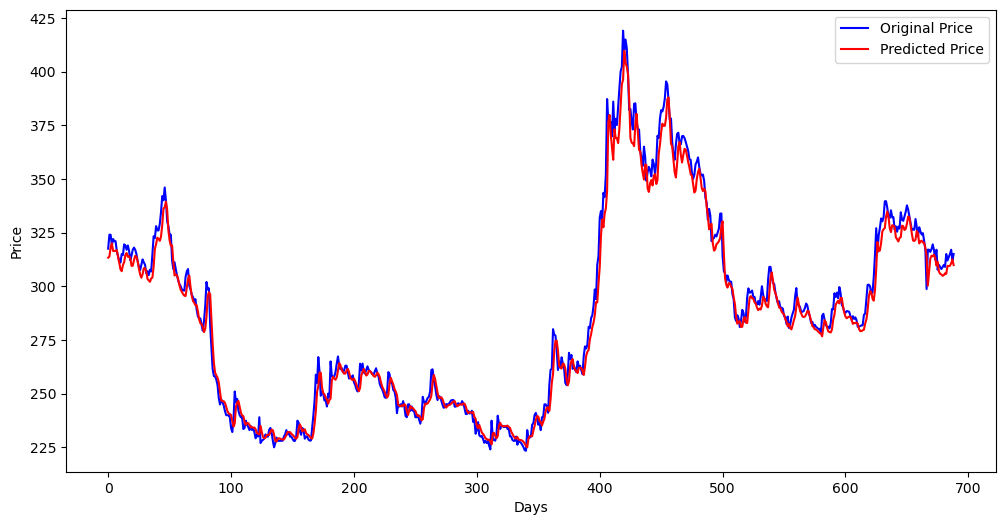

In [76]:
plt.figure(figsize = (12,6))
plt.plot(y_test, 'b', label = 'Original Price')
plt.plot(y_predicted, 'r', label = 'Predicted Price')
plt.xlabel('Days')
plt.ylabel('Price')
plt.legend()

(225.0, 425.0)

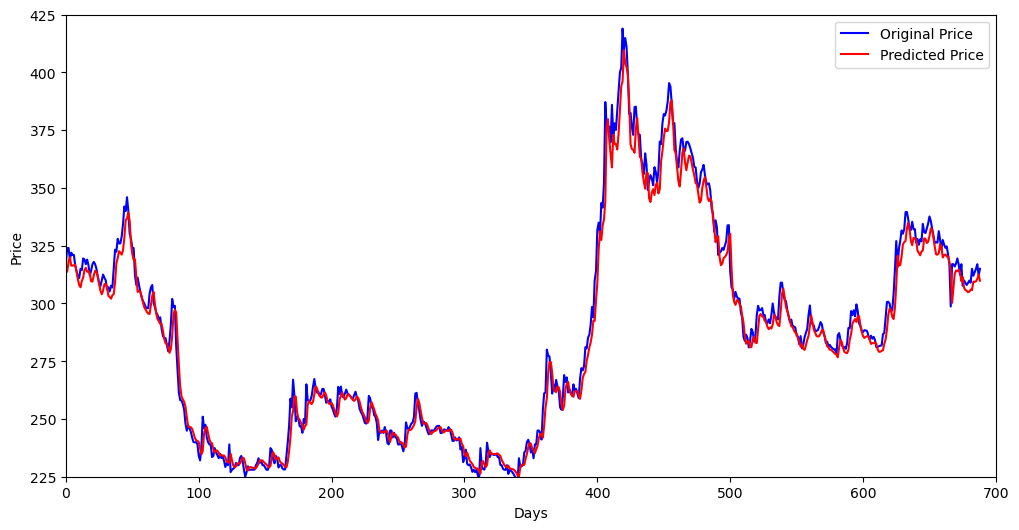

In [75]:
plt.figure(figsize = (12,6))
plt.plot(y_test, 'b', label = 'Original Price')
plt.plot(y_predicted, 'r', label = 'Predicted Price')
plt.xlabel('Days')
plt.ylabel('Price')
plt.legend()
plt.xlim(0,700)
plt.ylim(225,425)

10. Model Evaluation

In [89]:
# Mean Squard Error(MSE)
from sklearn.metrics import mean_squared_error,r2_score

In [86]:
mse = mean_squared_error(y_test, y_predicted)
print(f"Mean Squared Error (MSE): {mse}")

Mean Squared Error (MSE): 37.84904329695101


In [88]:
# Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)
print(f"Root Mean Squared Error (RMSE): {rmse}")

Root Mean Squared Error (RMSE): 6.1521576131428075


In [90]:
# R-Squared 
r2 = r2_score(y_test, y_predicted)
print(f"R-Squared: {r2}")

R-Squared: 0.9815121244374814
